# EDA for Google Apps Review
## Studi Kasus: Aplikasi Spotify

In [2]:
import pandas as pd

# Tentukan path file dataset Spotify
file_path = '../out/rawdata_spotify_id.csv'

# Baca file CSV ke dalam DataFrame
df_spotifyrev = pd.read_csv(file_path, low_memory=False)

# Tampilkan beberapa baris pertama
df_spotifyrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


# Exploratory Data Analysis (EDA) — Ulasan Aplikasi Spotify

## Import Required Libraries
Mengimpor pustaka yang diperlukan untuk analisis data, visualisasi, dan pemrosesan teks.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
from nltk.corpus import stopwords

## Download Stopwords
Mengunduh daftar stopwords bahasa Indonesia dari NLTK untuk kebutuhan pemrosesan teks.

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /home/ergia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ergia/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/ergia/nltk_data...


True

## Data Overview
Menampilkan informasi dasar dataset termasuk nama kolom, tipe data, dan beberapa baris pertama.

In [7]:
# Konversi kolom 'at' ke format datetime
df_spotifyrev['at'] = pd.to_datetime(df_spotifyrev['at'])

# Tampilkan info dataset
df_spotifyrev.info()
df_spotifyrev.head()

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              482756 non-null  str           
 1   userName              482756 non-null  str           
 2   userImage             482756 non-null  str           
 3   content               482741 non-null  str           
 4   score                 482756 non-null  int64         
 5   thumbsUpCount         482756 non-null  int64         
 6   reviewCreatedVersion  326735 non-null  str           
 7   at                    482756 non-null  datetime64[us]
 8   replyContent          4903 non-null    str           
 9   repliedAt             4903 non-null    str           
 10  appVersion            326735 non-null  str           
dtypes: datetime64[us](1), int64(2), str(8)
memory usage: 40.5 MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


## Missing Values Analysis
Mengidentifikasi dan menghitung jumlah nilai kosong pada setiap kolom.

In [8]:
missing_values = df_spotifyrev.isnull().sum()
print('Missing Values Summary:')
print(missing_values)

Missing Values Summary:
reviewId                     0
userName                     0
userImage                    0
content                     15
score                        0
thumbsUpCount                0
reviewCreatedVersion    156021
at                           0
replyContent            477853
repliedAt               477853
appVersion              156021
dtype: int64


## Review Score Distribution
Memvisualisasikan distribusi skor ulasan untuk memahami sentimen pengguna secara keseluruhan.

/tmp/ipykernel_310580/3149255637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_spotifyrev['score'], palette='viridis')


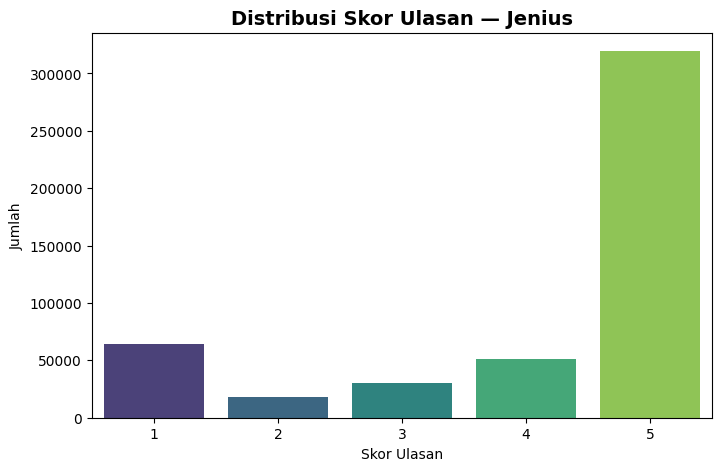

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_spotifyrev['score'], palette='viridis')
plt.title('Distribusi Skor Ulasan — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah')
plt.show()

## Review Trends Over Time
Menganalisis bagaimana jumlah ulasan berubah dari waktu ke waktu untuk mendeteksi pola tertentu.

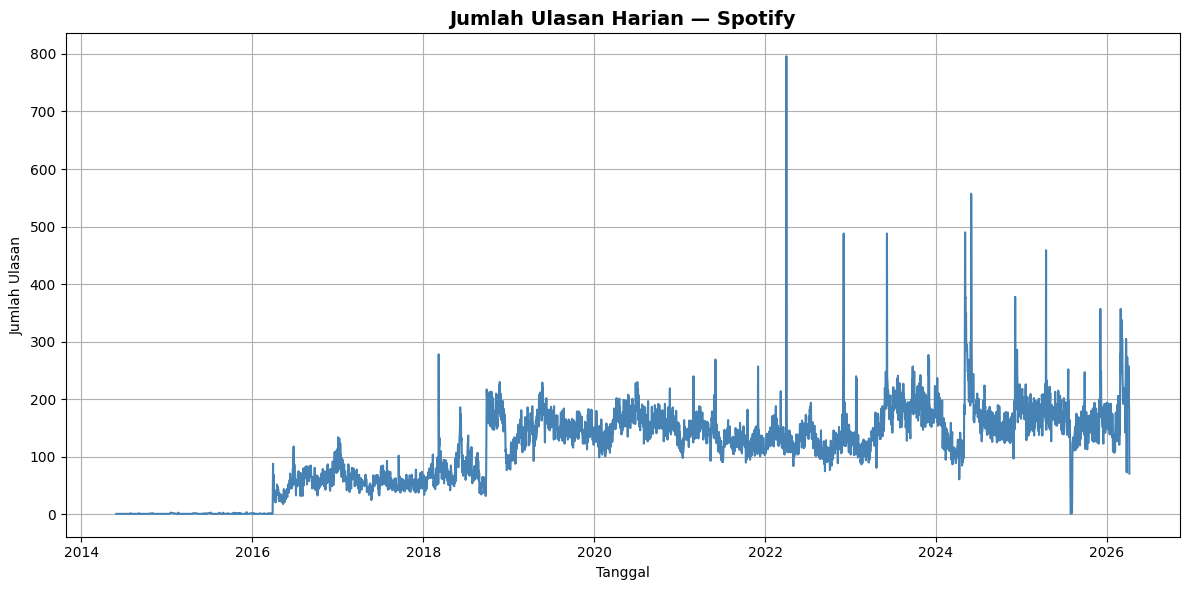

In [11]:
# Ekstrak tanggal ulasan
df_spotifyrev['review_date'] = df_spotifyrev['at'].dt.date
review_trend = df_spotifyrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot(color='steelblue')
plt.title('Jumlah Ulasan Harian — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Ulasan')
plt.grid(True)
plt.tight_layout()
plt.show()

## Word Frequency Analysis
Menganalisis kata-kata yang paling sering muncul dalam ulasan, dengan mengecualikan stopwords bahasa Indonesia.

In [12]:
# Muat stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Gabungkan seluruh teks ulasan
all_reviews = ' '.join(df_spotifyrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans('', '', string.punctuation))

# Tokenisasi dan filter stopwords
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Hitung frekuensi kata
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print('Most Common Words in Reviews:')
print(common_words)

Most Common Words in Reviews:
        Word  Frequency
0      bagus      93242
1       lagu      77506
2        nya      44712
3   aplikasi      34756
4    spotify      34477
5      iklan      33126
6     banget      29423
7    premium      28152
8       suka      27009
9       good      26331
10    mantap      25062
11        yg      24879
12     musik      22942
13        ga      18093
14       gak      17077
15     keren      16750
16       aja      16556
17        ok      16235
18   lagunya      15199
19        ya      14637


## Word Frequency Visualization
Memvisualisasikan kata-kata yang paling sering muncul dalam bentuk diagram batang horizontal.

/tmp/ipykernel_310580/2373911081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words, palette='Blues_r')


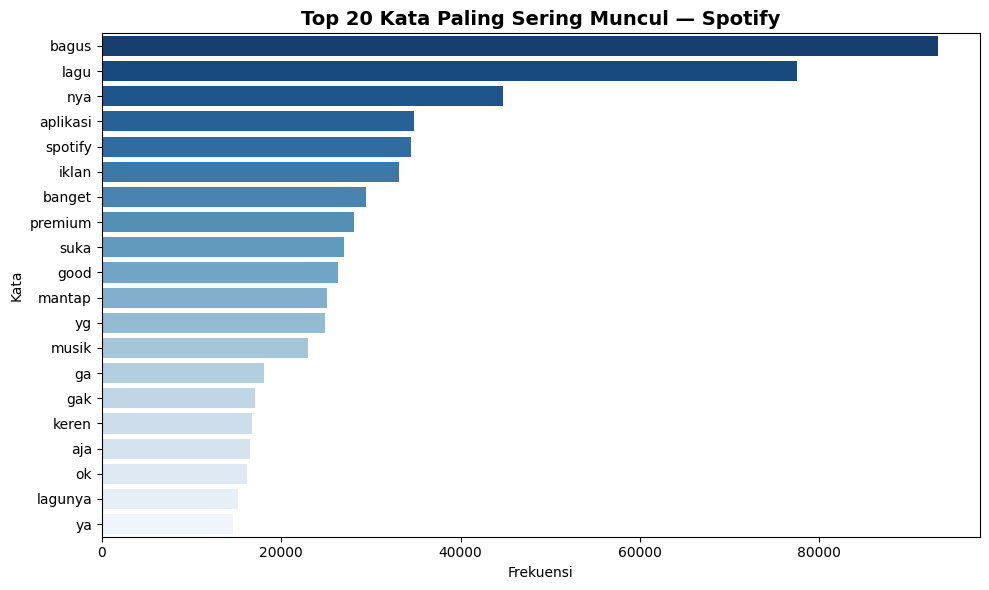

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=common_words, palette='Blues_r')
plt.title('Top 20 Kata Paling Sering Muncul — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

## Sentiment Distribution (Positive, Neutral, Negative)
Melabeli setiap ulasan berdasarkan skor rating menjadi tiga kategori sentimen: Positif, Netral, dan Negatif.

/tmp/ipykernel_310580/1348548799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


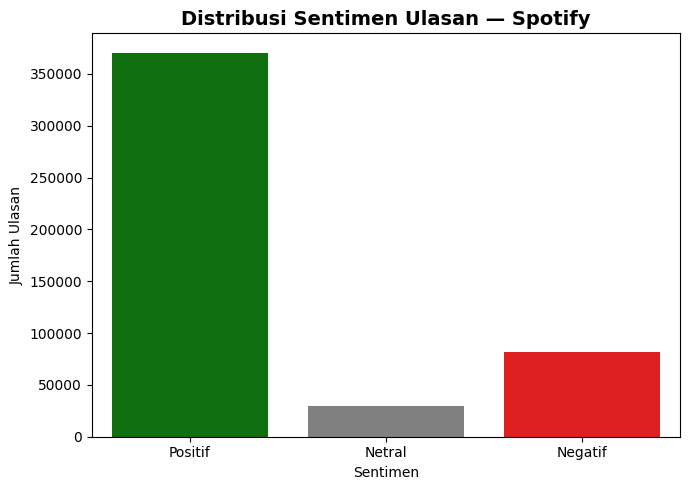


Jumlah per Sentimen:
sentiment
Positif    370670
Negatif     82011
Netral      30075
Name: count, dtype: int64


In [14]:
# Labeling sentimen berdasarkan skor rating
df_spotifyrev['sentiment'] = df_spotifyrev['score'].apply(
    lambda x: 'Positif' if x >= 4 else ('Netral' if x == 3 else 'Negatif')
)

plt.figure(figsize=(7, 5))
sns.countplot(
    x='sentiment', data=df_spotifyrev,
    palette={'Positif': 'green', 'Netral': 'gray', 'Negatif': 'red'},
    order=['Positif', 'Netral', 'Negatif']
)
plt.title('Distribusi Sentimen Ulasan — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()

print('\nJumlah per Sentimen:')
print(df_spotifyrev['sentiment'].value_counts())

## Word Frequency by Sentiment
Menganalisis kata-kata yang paling sering muncul secara terpisah pada ulasan Positif dan Negatif
untuk mengekstraksi insight dari masing-masing kelompok sentimen.

/tmp/ipykernel_310580/1455501093.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_pos, palette='Greens_r', ax=axes[0])
/tmp/ipykernel_310580/1455501093.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_neg, palette='Reds_r', ax=axes[1])


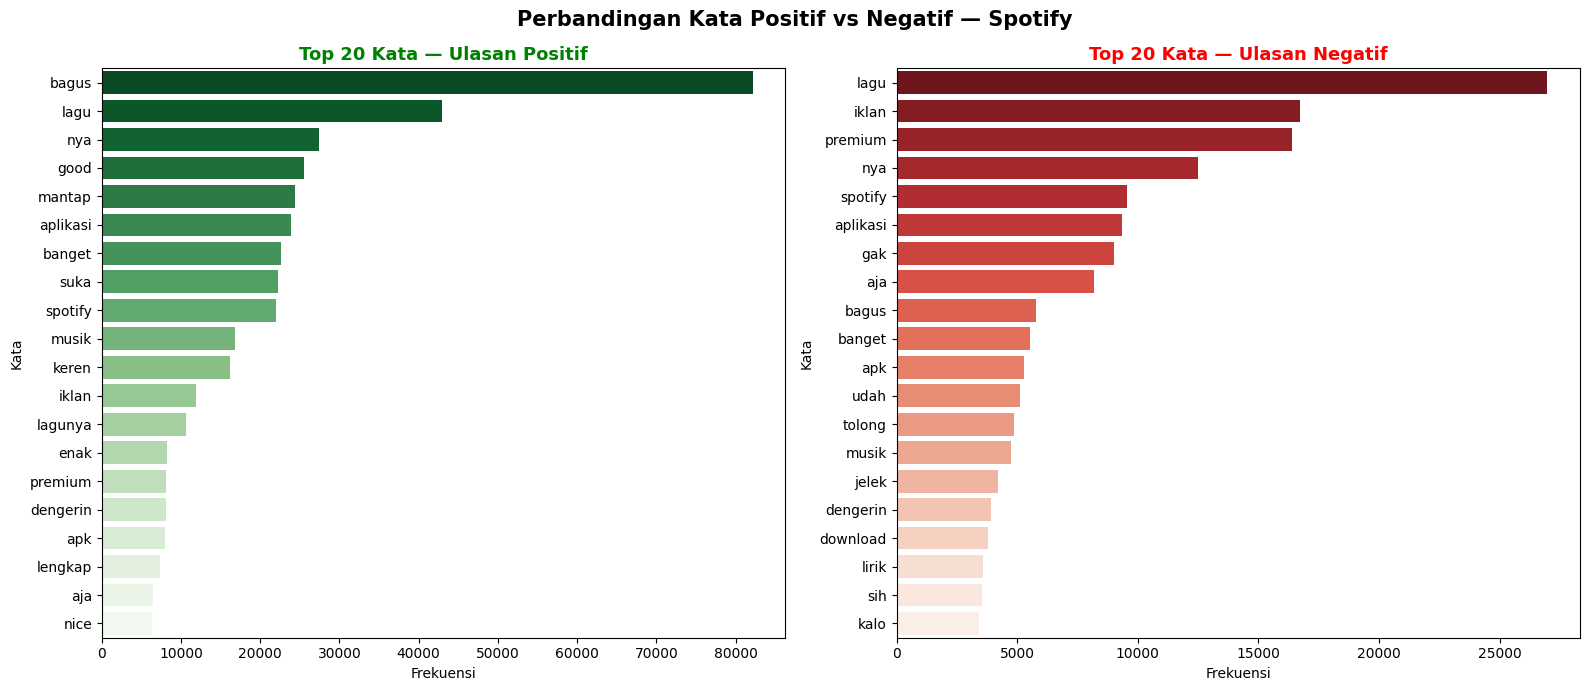


Most Common Words — Ulasan Positif:
        Word  Frequency
0      bagus      82137
1       lagu      43004
2        nya      27369
3       good      25539
4     mantap      24359
5   aplikasi      23826
6     banget      22662
7       suka      22273
8    spotify      22053
9      musik      16791
10     keren      16212
11     iklan      11939
12   lagunya      10688
13      enak       8234
14   premium       8127
15  dengerin       8058
16       apk       8041
17   lengkap       7408
18       aja       6510
19      nice       6300

Most Common Words — Ulasan Negatif:
        Word  Frequency
0       lagu      26986
1      iklan      16744
2    premium      16403
3        nya      12484
4    spotify       9555
5   aplikasi       9348
6        gak       9009
7        aja       8173
8      bagus       5771
9     banget       5538
10       apk       5280
11      udah       5093
12    tolong       4853
13     musik       4750
14     jelek       4182
15  dengerin       3891
16  download  

In [15]:
def get_top_words(df, sentiment_label, n=20):
    """Mengambil n kata terbanyak dari kelompok sentimen tertentu."""
    reviews = ' '.join(df[df['sentiment'] == sentiment_label]['content'].dropna()).lower()
    reviews = reviews.translate(str.maketrans('', '', string.punctuation))
    words = [w for w in reviews.split() if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

# Ambil top kata positif dan negatif
top_positif = get_top_words(df_spotifyrev, 'Positif')
top_negatif = get_top_words(df_spotifyrev, 'Negatif')

df_top_pos = pd.DataFrame(top_positif, columns=['Word', 'Frequency'])
df_top_neg = pd.DataFrame(top_negatif, columns=['Word', 'Frequency'])

# Visualisasi berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x='Frequency', y='Word', data=df_top_pos, palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 20 Kata — Ulasan Positif', fontsize=13, fontweight='bold', color='green')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Kata')

sns.barplot(x='Frequency', y='Word', data=df_top_neg, palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 20 Kata — Ulasan Negatif', fontsize=13, fontweight='bold', color='red')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Kata')

plt.suptitle('Perbandingan Kata Positif vs Negatif — Spotify', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMost Common Words — Ulasan Positif:')
print(df_top_pos)
print('\nMost Common Words — Ulasan Negatif:')
print(df_top_neg)

## Monthly Review Trend
Menganalisis tren jumlah ulasan per bulan untuk melihat fluktuasi aktivitas pengguna
dalam memberikan umpan balik terhadap aplikasi Spotify.

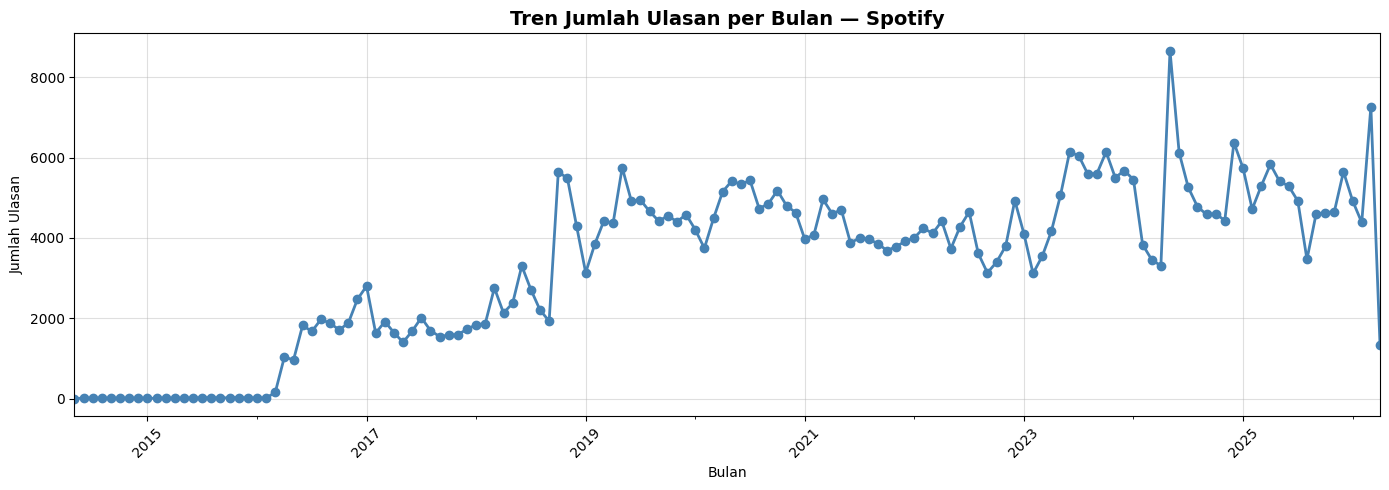

In [16]:
# Tambahkan kolom bulan-tahun
df_spotifyrev['year_month'] = df_spotifyrev['at'].dt.to_period('M')
monthly_trend = df_spotifyrev.groupby('year_month').size()

plt.figure(figsize=(14, 5))
monthly_trend.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Tren Jumlah Ulasan per Bulan — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Average Score per Year
Menghitung rata-rata skor ulasan per tahun untuk mengevaluasi tren kepuasan pengguna
terhadap aplikasi Spotify secara kronologis.

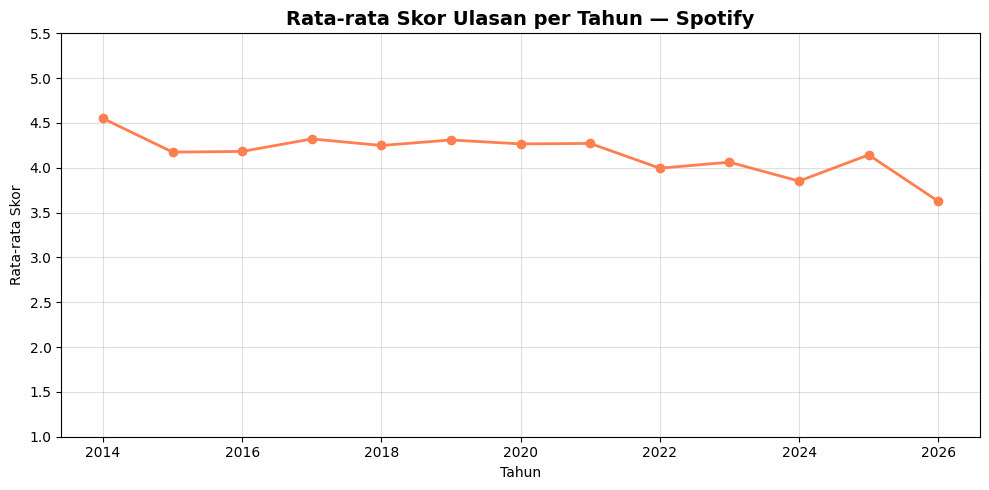

In [17]:
# Tambahkan kolom tahun
df_spotifyrev['year'] = df_spotifyrev['at'].dt.year
avg_score_year = df_spotifyrev.groupby('year')['score'].mean()

plt.figure(figsize=(10, 5))
avg_score_year.plot(marker='o', color='coral', linewidth=2)
plt.title('Rata-rata Skor Ulasan per Tahun — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Skor')
plt.ylim(1, 5.5)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Review Length Analysis
Menganalisis panjang teks ulasan (jumlah karakter) untuk memahami seberapa deskriptif
pengguna dalam menyampaikan umpan balik pada setiap kategori skor.

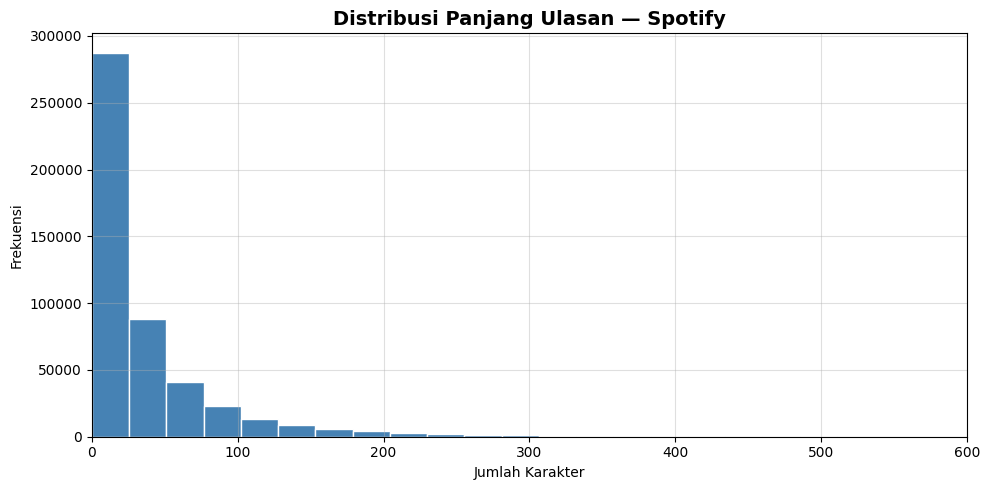


Statistik Panjang Ulasan per Skor:
        count       mean  median   max
score                                 
1       64388  69.115177    44.0  1277
2       17623  82.725529    56.0   744
3       30075  61.461513    36.0   636
4       51152  41.699425    20.0   954
5      319518  26.883284    13.0  1042


In [19]:
# Hitung panjang setiap ulasan
df_spotifyrev['review_length'] = df_spotifyrev['content'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 5))
plt.hist(df_spotifyrev['review_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Panjang Ulasan — Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Statistik deskriptif panjang ulasan per skor
print('\nStatistik Panjang Ulasan per Skor:')
print(df_spotifyrev.groupby('score')['review_length'].agg(['count', 'mean', 'median', 'max']))

## Developer Reply Rate
Mengukur tingkat responsivitas pengembang terhadap ulasan pengguna dengan menghitung
persentase ulasan yang mendapatkan balasan dari pihak Spotify.

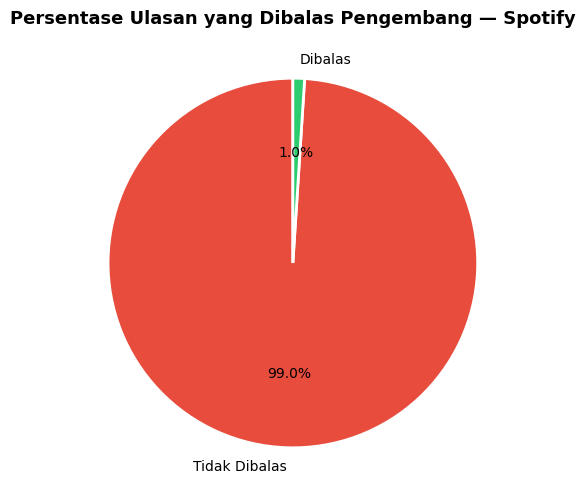

Dibalas       : 4,903 (1.0%)
Tidak Dibalas : 477,853 (99.0%)


In [20]:
import matplotlib.pyplot as plt

# 1. Tandai ulasan yang mendapat balasan
df_spotifyrev['is_replied'] = df_spotifyrev['replyContent'].notnull()
reply_counts = df_spotifyrev['is_replied'].value_counts()

# 2. Buat mapping label agar tidak error jika salah satu kategori kosong
label_map = {True: 'Dibalas', False: 'Tidak Dibalas'}
current_labels = [label_map[idx] for idx in reply_counts.index]

# 3. Warna yang menyesuaikan index (Merah untuk False, Hijau untuk True)
color_map = {False: '#e74c3c', True: '#2ecc71'}
current_colors = [color_map[idx] for idx in reply_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    reply_counts,
    labels=current_labels, # Label otomatis sesuai data yang ada
    autopct='%1.1f%%',
    colors=current_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    startangle=90 # Biar posisi pie chart-nya lebih rapi
)

plt.title('Persentase Ulasan yang Dibalas Pengembang — Spotify',
          fontsize=13, fontweight='bold')
plt.show()

# 4. Print statistik dengan handling error jika salah satu index tidak ada
total = reply_counts.sum()
cnt_true = reply_counts.get(True, 0)
cnt_false = reply_counts.get(False, 0)

print(f'Dibalas       : {cnt_true:,} ({cnt_true/total*100:.1f}%)')
print(f'Tidak Dibalas : {cnt_false:,} ({cnt_false/total*100:.1f}%)')

## Summary Statistics
Menampilkan ringkasan statistik deskriptif dari seluruh dataset ulasan Spotify
sebagai validasi akhir sebelum tahap analisis lebih lanjut.

In [21]:
# Ringkasan statistik deskriptif
print('=== RINGKASAN DATASET ULASAN SPOTIFY ===')
print(f'Total ulasan       : {len(df_spotifyrev):,}')
print(f'Rentang waktu      : {df_spotifyrev["at"].min().date()} s/d {df_spotifyrev["at"].max().date()}')
print(f'Rata-rata skor     : {df_spotifyrev["score"].mean():.2f}')
print(f'Median skor        : {df_spotifyrev["score"].median()}')
print(f'Ulasan dibalas     : {df_spotifyrev["is_replied"].sum():,}')
print()
df_spotifyrev.describe()

=== RINGKASAN DATASET ULASAN SPOTIFY ===
Total ulasan       : 482,756
Rentang waktu      : 2014-05-30 s/d 2026-04-07
Rata-rata skor     : 4.13
Median skor        : 5.0
Ulasan dibalas     : 4,903



,score,thumbsUpCount,at,year,review_length
count,482756.000000,482756.000000,482756,482756.000000,482756.000000
mean,4.126426,2.135628,2022-01-02 18:30:58.173487,2021.502854,38.278586
min,1.000000,0.000000,2014-05-30 07:47:46,2014.000000,0.000000
25%,4.000000,0.000000,2019-11-14 21:58:51,2019.000000,6.000000
50%,5.000000,0.000000,2022-02-17 08:11:41,2022.000000,18.000000
75%,5.000000,0.000000,2024-05-08 07:20:44,2024.000000,46.000000
max,5.000000,8338.000000,2026-04-07 13:41:34,2026.000000,1277.000000
std,1.433382,48.219928,NaN,2.680129,55.947414
